### Part I: Single-Model Calibration

#### Name: Tracy Chen, Hayley Shin (Group No: 7)



#### I.1 Warm-up: one simple Scattergories question

Goal: get the LLM to pick days of the week as uniformly as possible across different prompts and temperatures.

In [52]:
import math
import json
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from pathlib import Path

In [53]:
# Run each from terminal first:
#   python3 assignment3_starter.py calibrate --model qwen2.5:7b --task day --samples 500 \
#     --prompt-file prompts/day/baseline.txt --prompt-id baseline --outdir outputs/day/baseline

DAYS = ["monday", "tuesday", "wednesday", "thursday", "friday", "saturday", "sunday"]

RUNS = [
    ("baseline",     "outputs/day/baseline"),
    ("dice_framing", "outputs/day/dice_framing"),
    ("lottery_mapping", "outputs/day/lottery_mapping"),
    ("entropy_framing", "outputs/day/entropy_framing"),
    ("modulo_framing", "outputs/day/modulo_framing"),
]

In [54]:
all_dfs     = {}   # prompt_id -> samples DataFrame
all_summary = {}   # prompt_id -> list of per-temperature dicts (from JSON)

for prompt_id, outdir in RUNS:
    csv_path  = Path(outdir) / "calibration_day_samples.csv"
    json_path = Path(outdir) / "calibration_day_summary.json"
    
    df = pd.read_csv(csv_path)
    df["answer_norm"] = df["answer_norm"].apply(lambda x: x if x in DAYS else "invalid")
    all_dfs[prompt_id] = df

    with open(json_path) as f:
        all_summary[prompt_id] = json.load(f)

print("Loaded:", list(all_dfs.keys()))

Loaded: ['baseline', 'dice_framing', 'lottery_mapping', 'entropy_framing', 'modulo_framing']


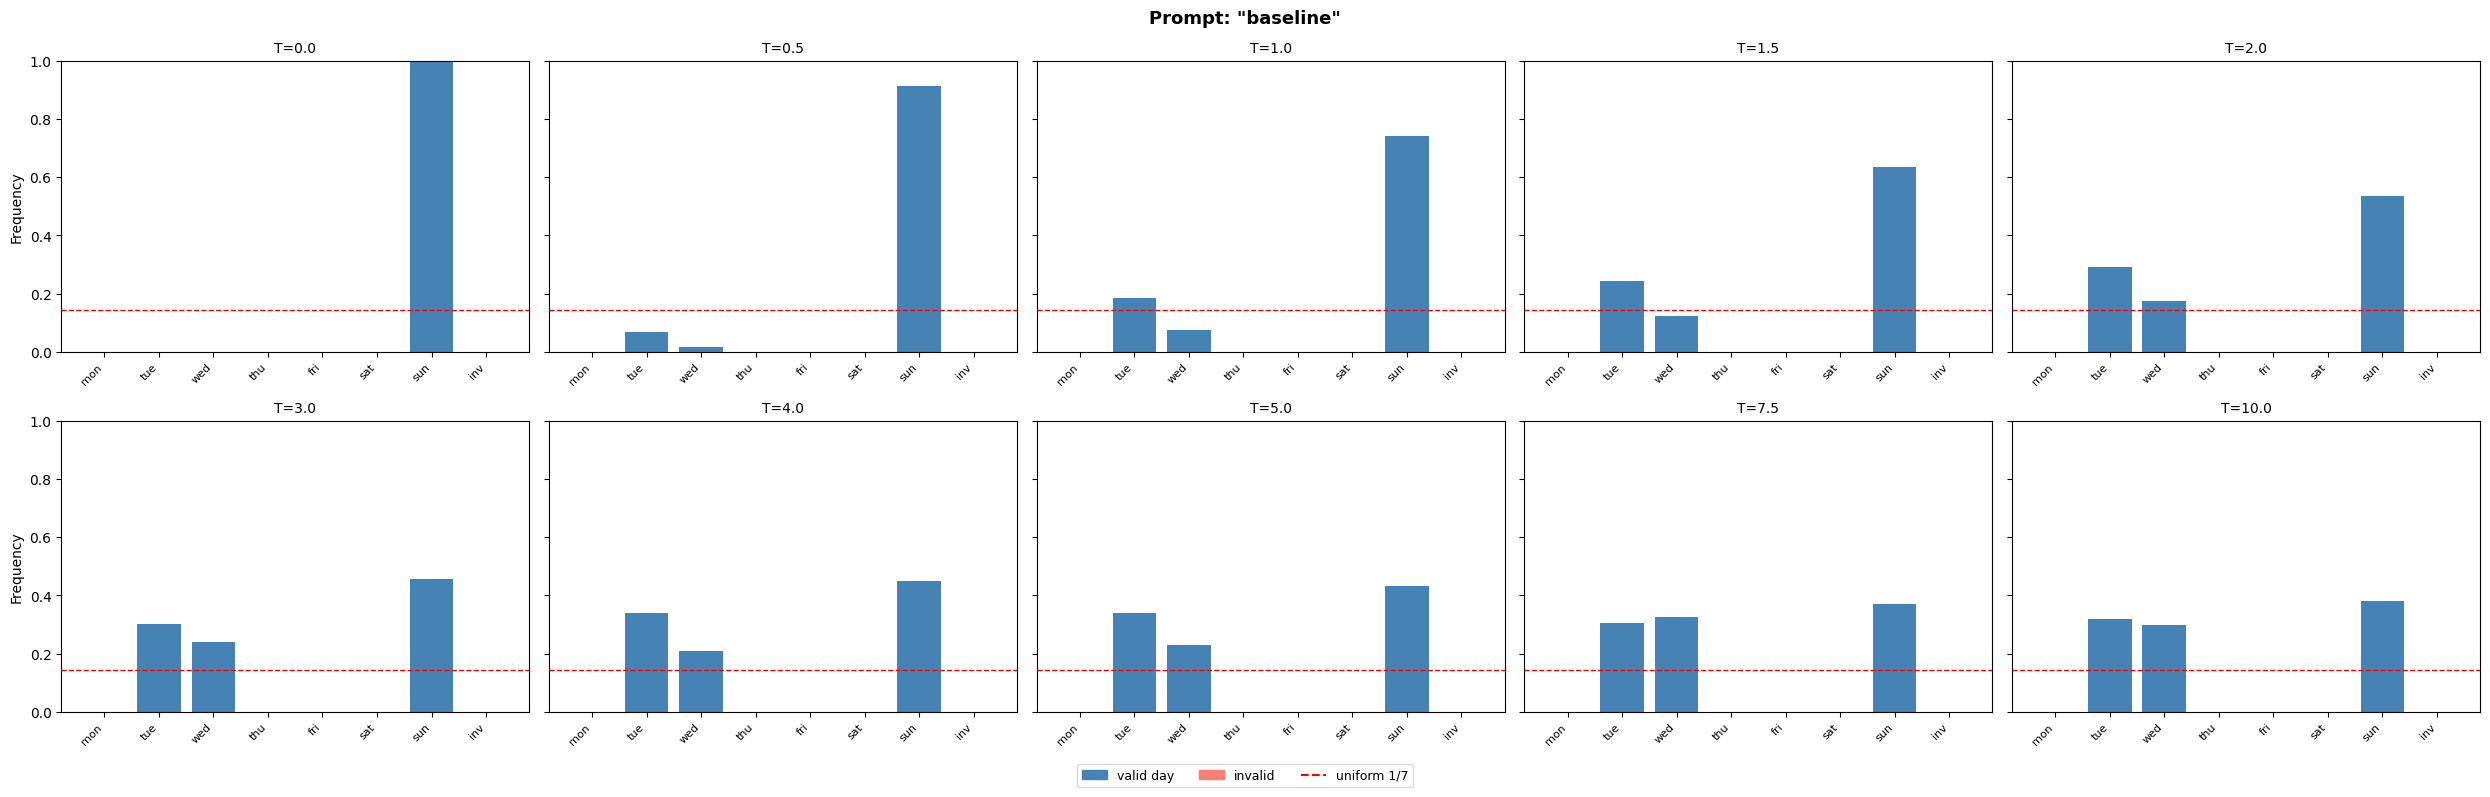

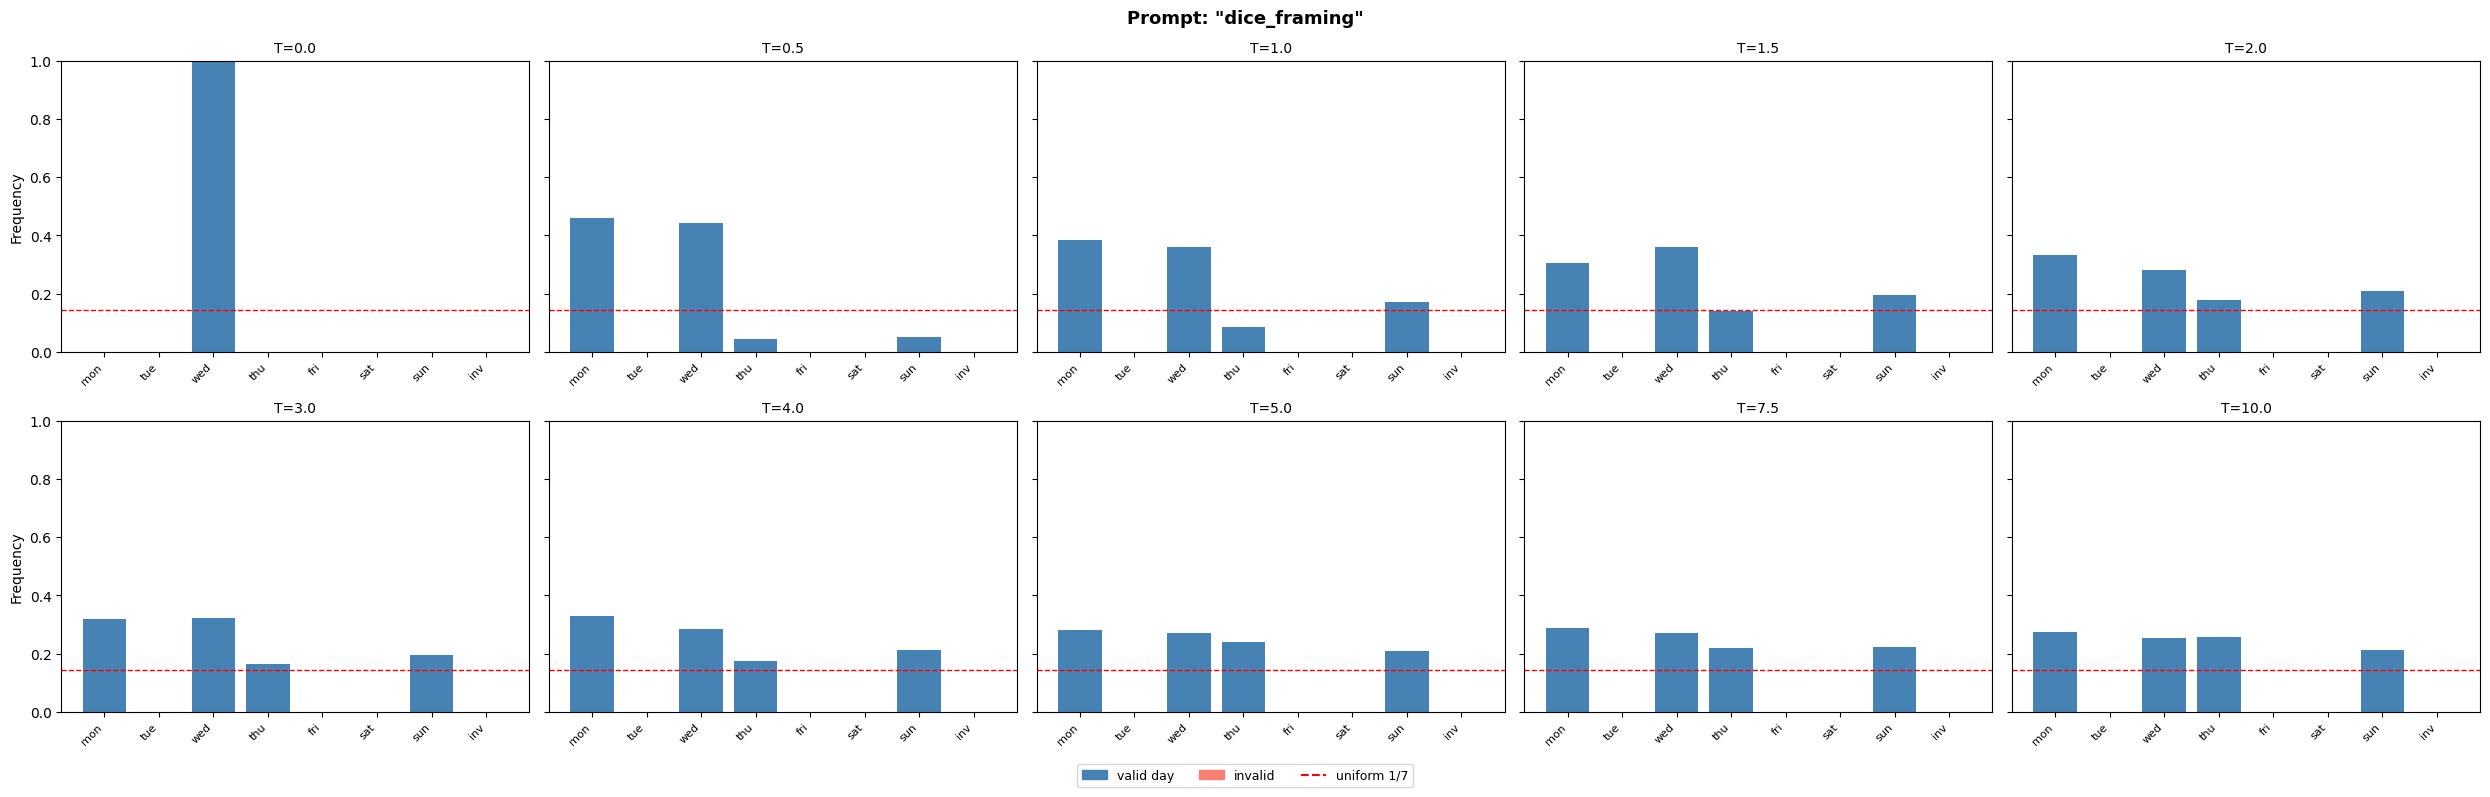

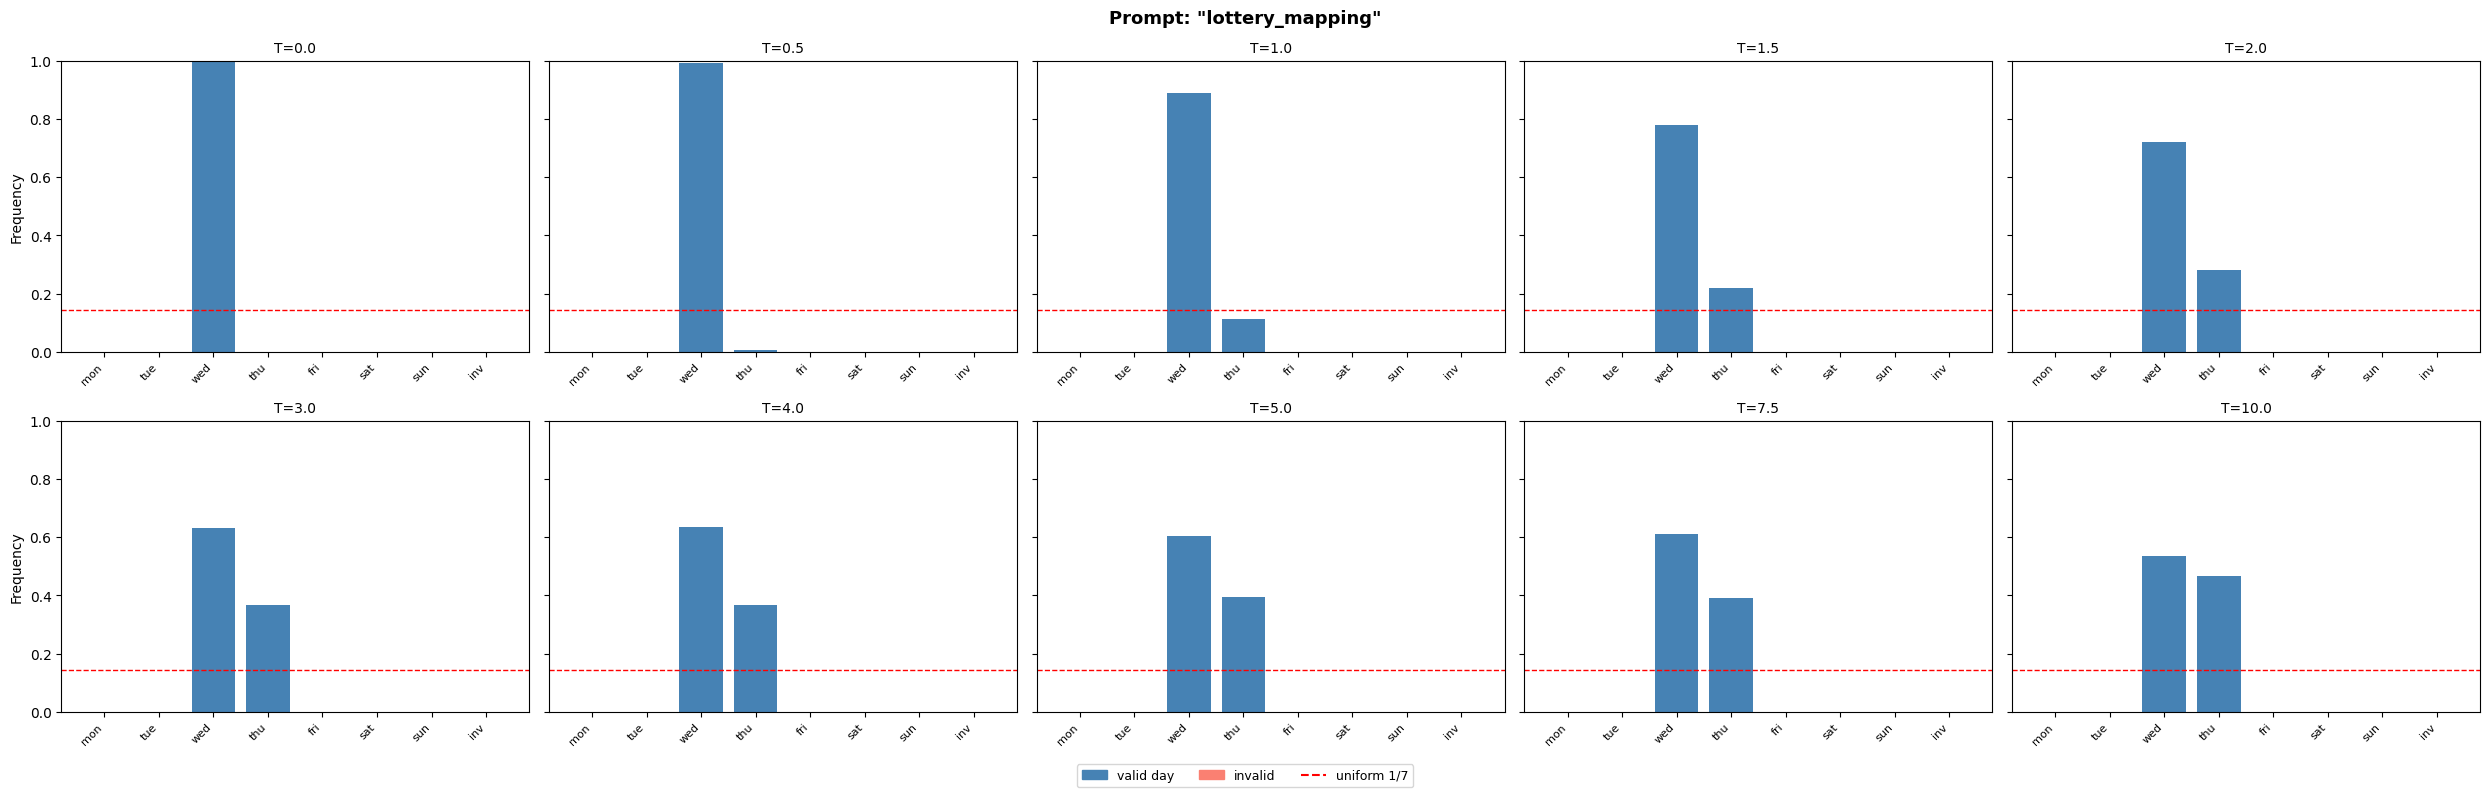

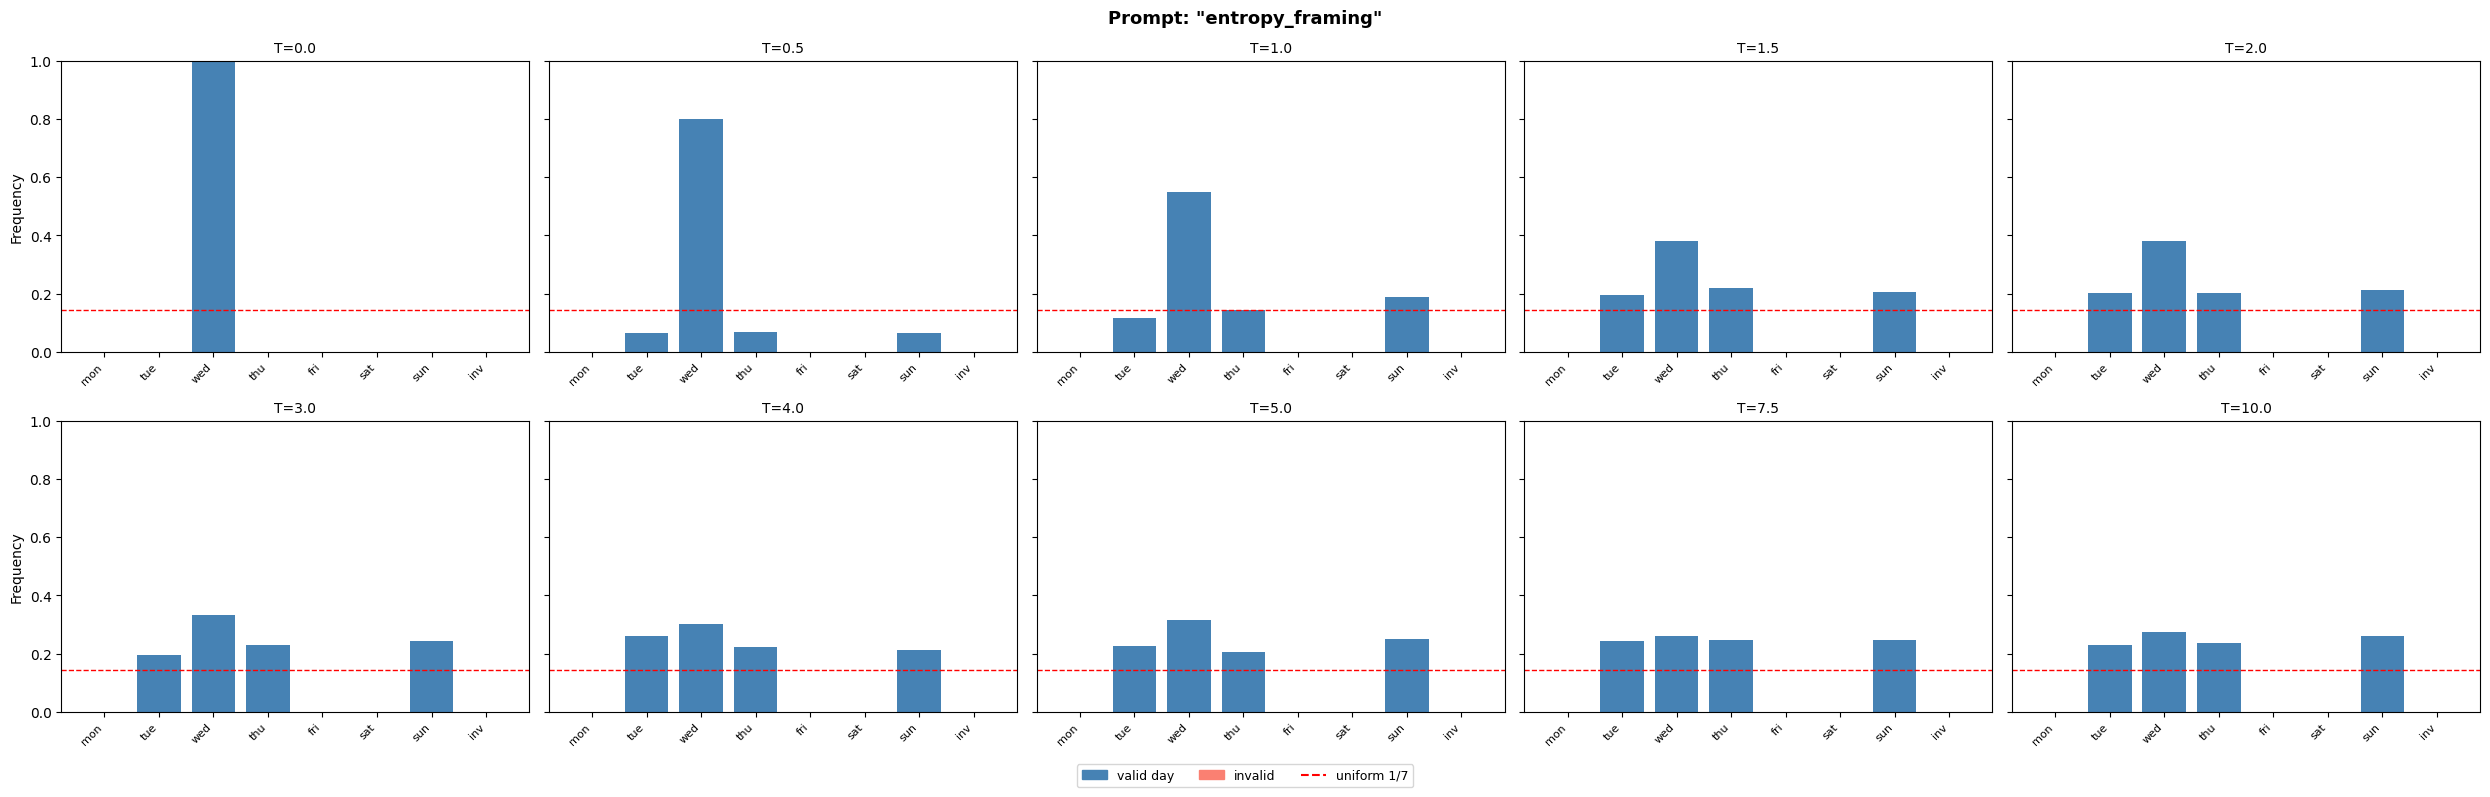

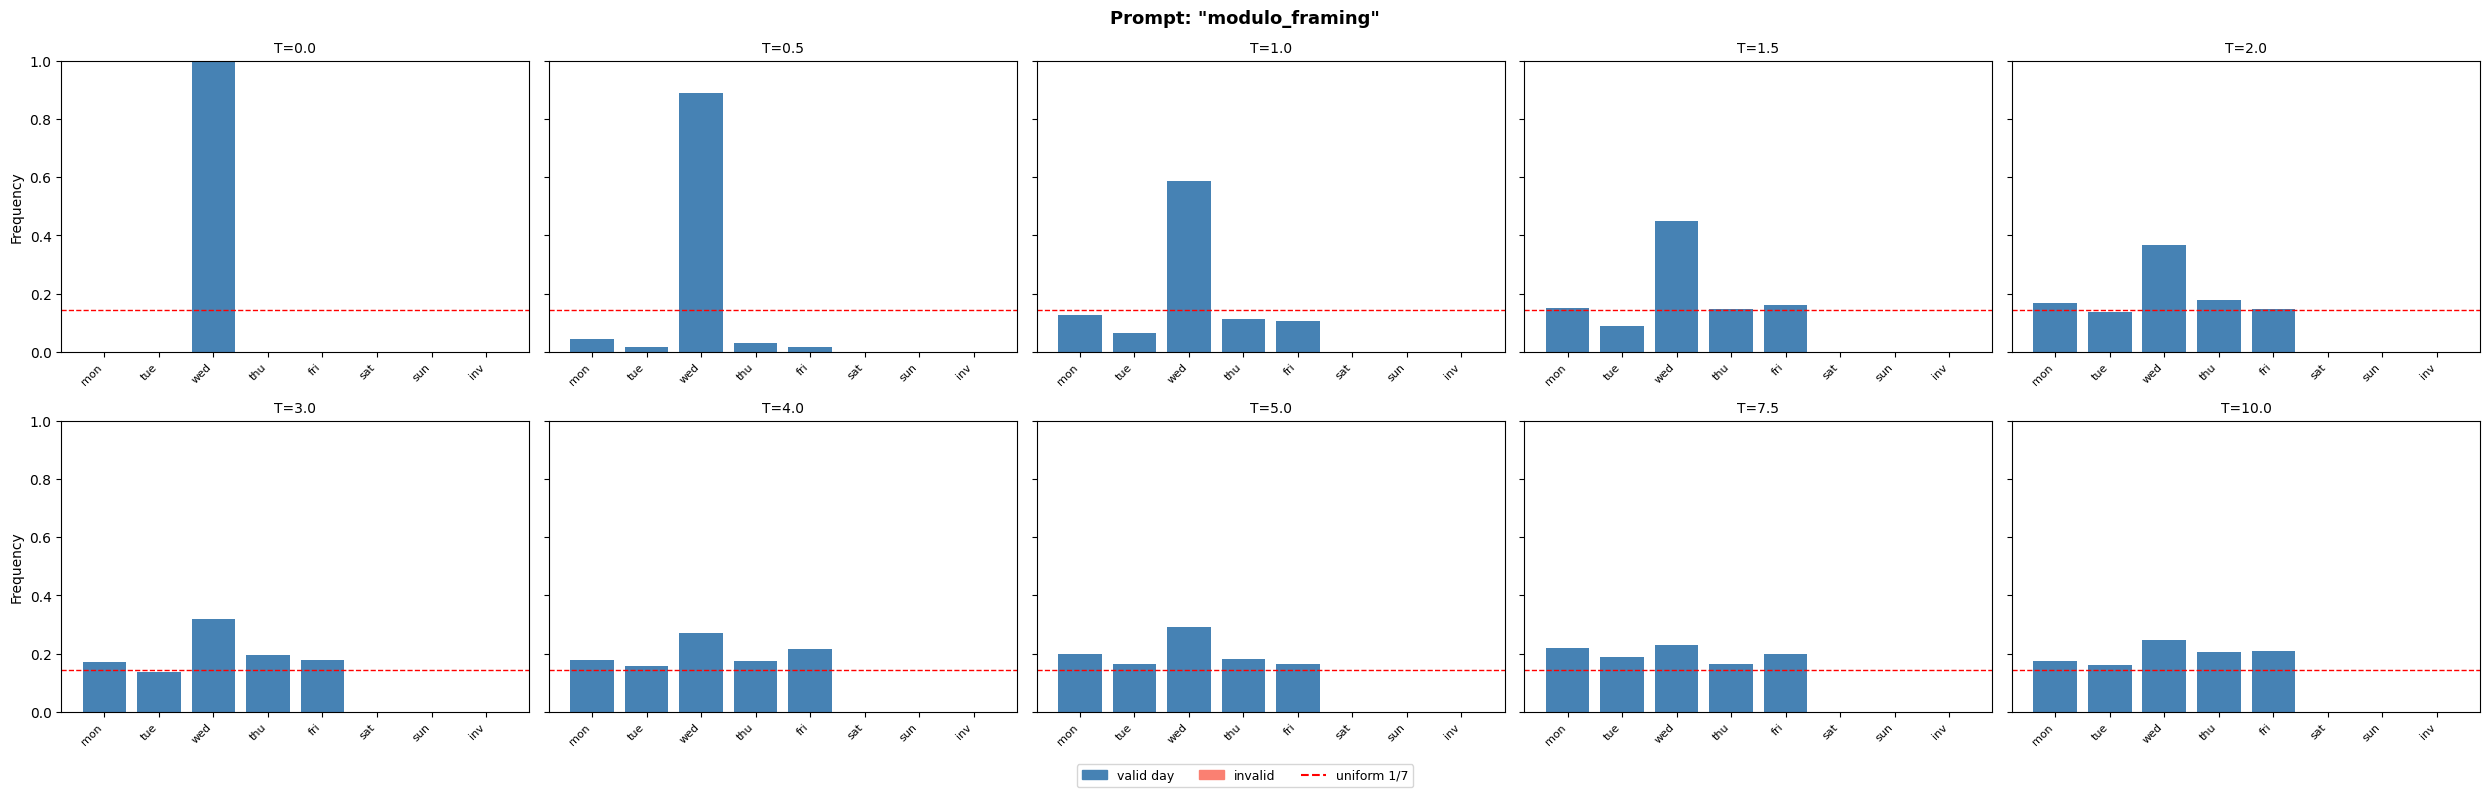

In [55]:
# print the histogram plots for each prompt_id and temperature 
NCOLS     = 5
uniform_p = 1 / 7
ALL_KEYS  = DAYS + ["invalid"]

for prompt_id, df in all_dfs.items():
    temperatures = sorted(df["temperature"].unique())
    n_temps = len(temperatures)
    nrows   = math.ceil(n_temps / NCOLS)

    fig, axes = plt.subplots(nrows, NCOLS, figsize=(5 * NCOLS, 4 * nrows), sharey=True)
    axes_flat = axes.flatten()
    fig.suptitle(f'Prompt: "{prompt_id}"', fontsize=13, fontweight="bold")

    for idx, temp in enumerate(temperatures):
        ax     = axes_flat[idx]
        sub_t  = df[df["temperature"] == temp]
        counts = Counter(sub_t["answer_norm"])

        freqs  = [counts.get(k, 0) / len(sub_t) for k in ALL_KEYS]
        colors = ["steelblue"] * len(DAYS) + ["salmon"]

        ax.bar(range(len(ALL_KEYS)), freqs, color=colors)
        ax.axhline(uniform_p, color="red", linestyle="--", linewidth=1)
        ax.set_xticks(range(len(ALL_KEYS)))
        ax.set_xticklabels([k[:3] for k in ALL_KEYS], rotation=45, ha="right", fontsize=8)
        ax.set_title(f"T={temp}", fontsize=10)
        ax.set_ylim(0, 1)
        if idx % NCOLS == 0:
            ax.set_ylabel("Frequency")

    for idx in range(n_temps, len(axes_flat)):
        axes_flat[idx].set_visible(False)

    handles = [
        plt.Rectangle((0,0),1,1, color="steelblue", label="valid day"),
        plt.Rectangle((0,0),1,1, color="salmon",    label="invalid"),
        plt.Line2D([0],[0], color="red", linestyle="--", label="uniform 1/7"),
    ]
    fig.legend(handles=handles, loc="lower center", ncol=3, fontsize=9, bbox_to_anchor=(0.5, 0))
    plt.tight_layout(rect=[0, 0.04, 1, 1])
    plt.savefig(f"outputs/day/_img/hist_day_{prompt_id}.png", dpi=120, bbox_inches="tight")
    plt.show()

In [56]:
# ── Entropy & Metrics — read directly from summary JSON ──────────────────────
# The JSON already has entropy_nats, kl_to_uniform, top_answers per temperature.

MAX_ENTROPY = math.log(7)   # ~1.946 nats
records = []

for prompt_id, summary in all_summary.items():
    for entry in summary:
        records.append({
            "prompt_id":    prompt_id,
            "temperature":  entry["temperature"],
            "entropy_nats": entry["entropy_nats"],
            "kl_uniform":   entry.get("kl_to_uniform", float("nan")),
            "unique_answers": entry["unique_answers"],
            "top_answers":  entry["top_answers"][:3],   # top 3 for display
        })

metrics = pd.DataFrame(records)
print(f"Max entropy (uniform over 7 days): {MAX_ENTROPY:.3f} nats\n")
metrics.drop(columns="top_answers")

Max entropy (uniform over 7 days): 1.946 nats



,prompt_id,temperature,entropy_nats,kl_uniform,unique_answers
0,baseline,0.0,0.000000,1.945910,1
1,baseline,0.5,0.334502,1.611408,3
2,baseline,1.0,0.728344,1.217566,3
3,baseline,1.5,0.889757,1.056154,3
4,baseline,2.0,0.998736,0.947174,3
5,baseline,3.0,1.061747,0.884163,3
6,baseline,4.0,1.053860,0.892050,3
7,baseline,5.0,1.067248,0.878662,3
8,baseline,7.5,1.095254,0.850656,3
9,baseline,10.0,1.093008,0.852902,3


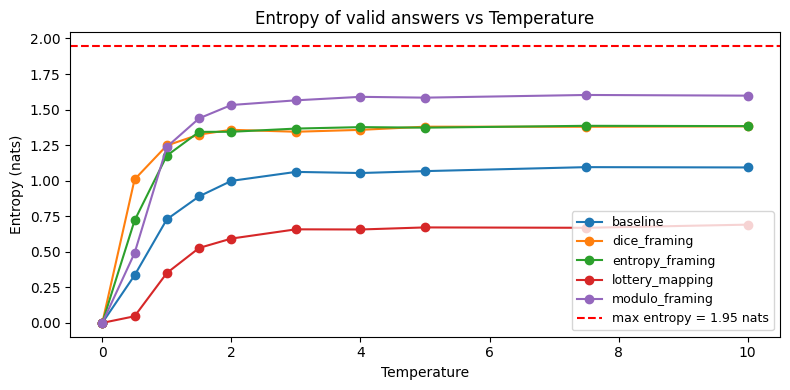

In [57]:
fig, ax = plt.subplots(figsize=(8, 4))

for prompt_id, grp in metrics.groupby("prompt_id"):
    ax.plot(grp["temperature"], grp["entropy_nats"], marker="o", label=prompt_id)

ax.axhline(MAX_ENTROPY, color="red", linestyle="--", label=f"max entropy = {MAX_ENTROPY:.2f} nats")
ax.set_xlabel("Temperature")
ax.set_ylabel("Entropy (nats)")
ax.set_title("Entropy of valid answers vs Temperature")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("outputs/entropy_vs_temp_day.png", dpi=120, bbox_inches="tight")
plt.show()

#### PartI.2 Next-token probabilities and top-k

In [61]:
import json
import urllib.request

def get_ollama_logprobs(model: str,prompt: str,temperature: float = 2.0,top_k: int = 40 ) -> dict:
    url = "http://localhost:11434/api/generate"
    
    payload = {
        "model": model,
        "prompt": prompt,
        "stream": False,
        "logprobs": True,       
        "top_logprobs": 10,     
        "options": {
            "temperature": temperature,
            "top_k": top_k,
            "num_predict": 1   
        }
    }
    
    req = urllib.request.Request(
        url,
        data=json.dumps(payload).encode("utf-8"),
        method="POST",
        headers={"Content-Type": "application/json"},
    )
    
    try:
        with urllib.request.urlopen(req, timeout=60) as resp:
            data = json.loads(resp.read().decode("utf-8"))
            
        if "logprobs" in data and data["logprobs"]:
            first_token_data = data["logprobs"][0]
            
            if "top_logprobs" in first_token_data:
                return {
                    item["token"]: item["logprob"] 
                    for item in first_token_data["top_logprobs"]
                }
                
        return {"error": "could not extract logprobs from response"}
        
    except Exception as e:
        return {"error": str(e)}

In [60]:
import math
from pathlib import Path

prompt_path = Path("prompts/day/modulo_framing.txt")
prompt = prompt_path.read_text(encoding="utf-8")
model_name = "qwen2.5:7b" 

logprobs_dict = get_ollama_logprobs(model=model_name, prompt=prompt)

if "error" in logprobs_dict:
    print("Error:", logprobs_dict["error"])
else:
    print(f"{'Token':<15} | {'Logprob':<10} | {'Probability (%)'}")
    print("-" * 45)
    
    total_prob = 0
    for token, logprob in logprobs_dict.items():
        prob = math.exp(logprob) * 100 
        total_prob += prob
        print(f"{repr(token):<15} | {logprob:<10.4f} | {prob:>6.2f}%")

Token           | Logprob    | Probability (%)
---------------------------------------------
'wed'           | -0.6056    |  54.57%
'th'            | -1.7969    |  16.58%
'fr'            | -2.2117    |  10.95%
't'             | -2.4660    |   8.49%
'mon'           | -3.0523    |   4.73%
's'             | -3.0830    |   4.58%
'mond'          | -8.0804    |   0.03%
' friday'       | -9.2348    |   0.01%
'Wednesday'     | -9.3525    |   0.01%
' wed'          | -9.4630    |   0.01%


#### Part I.3 Harder prompt

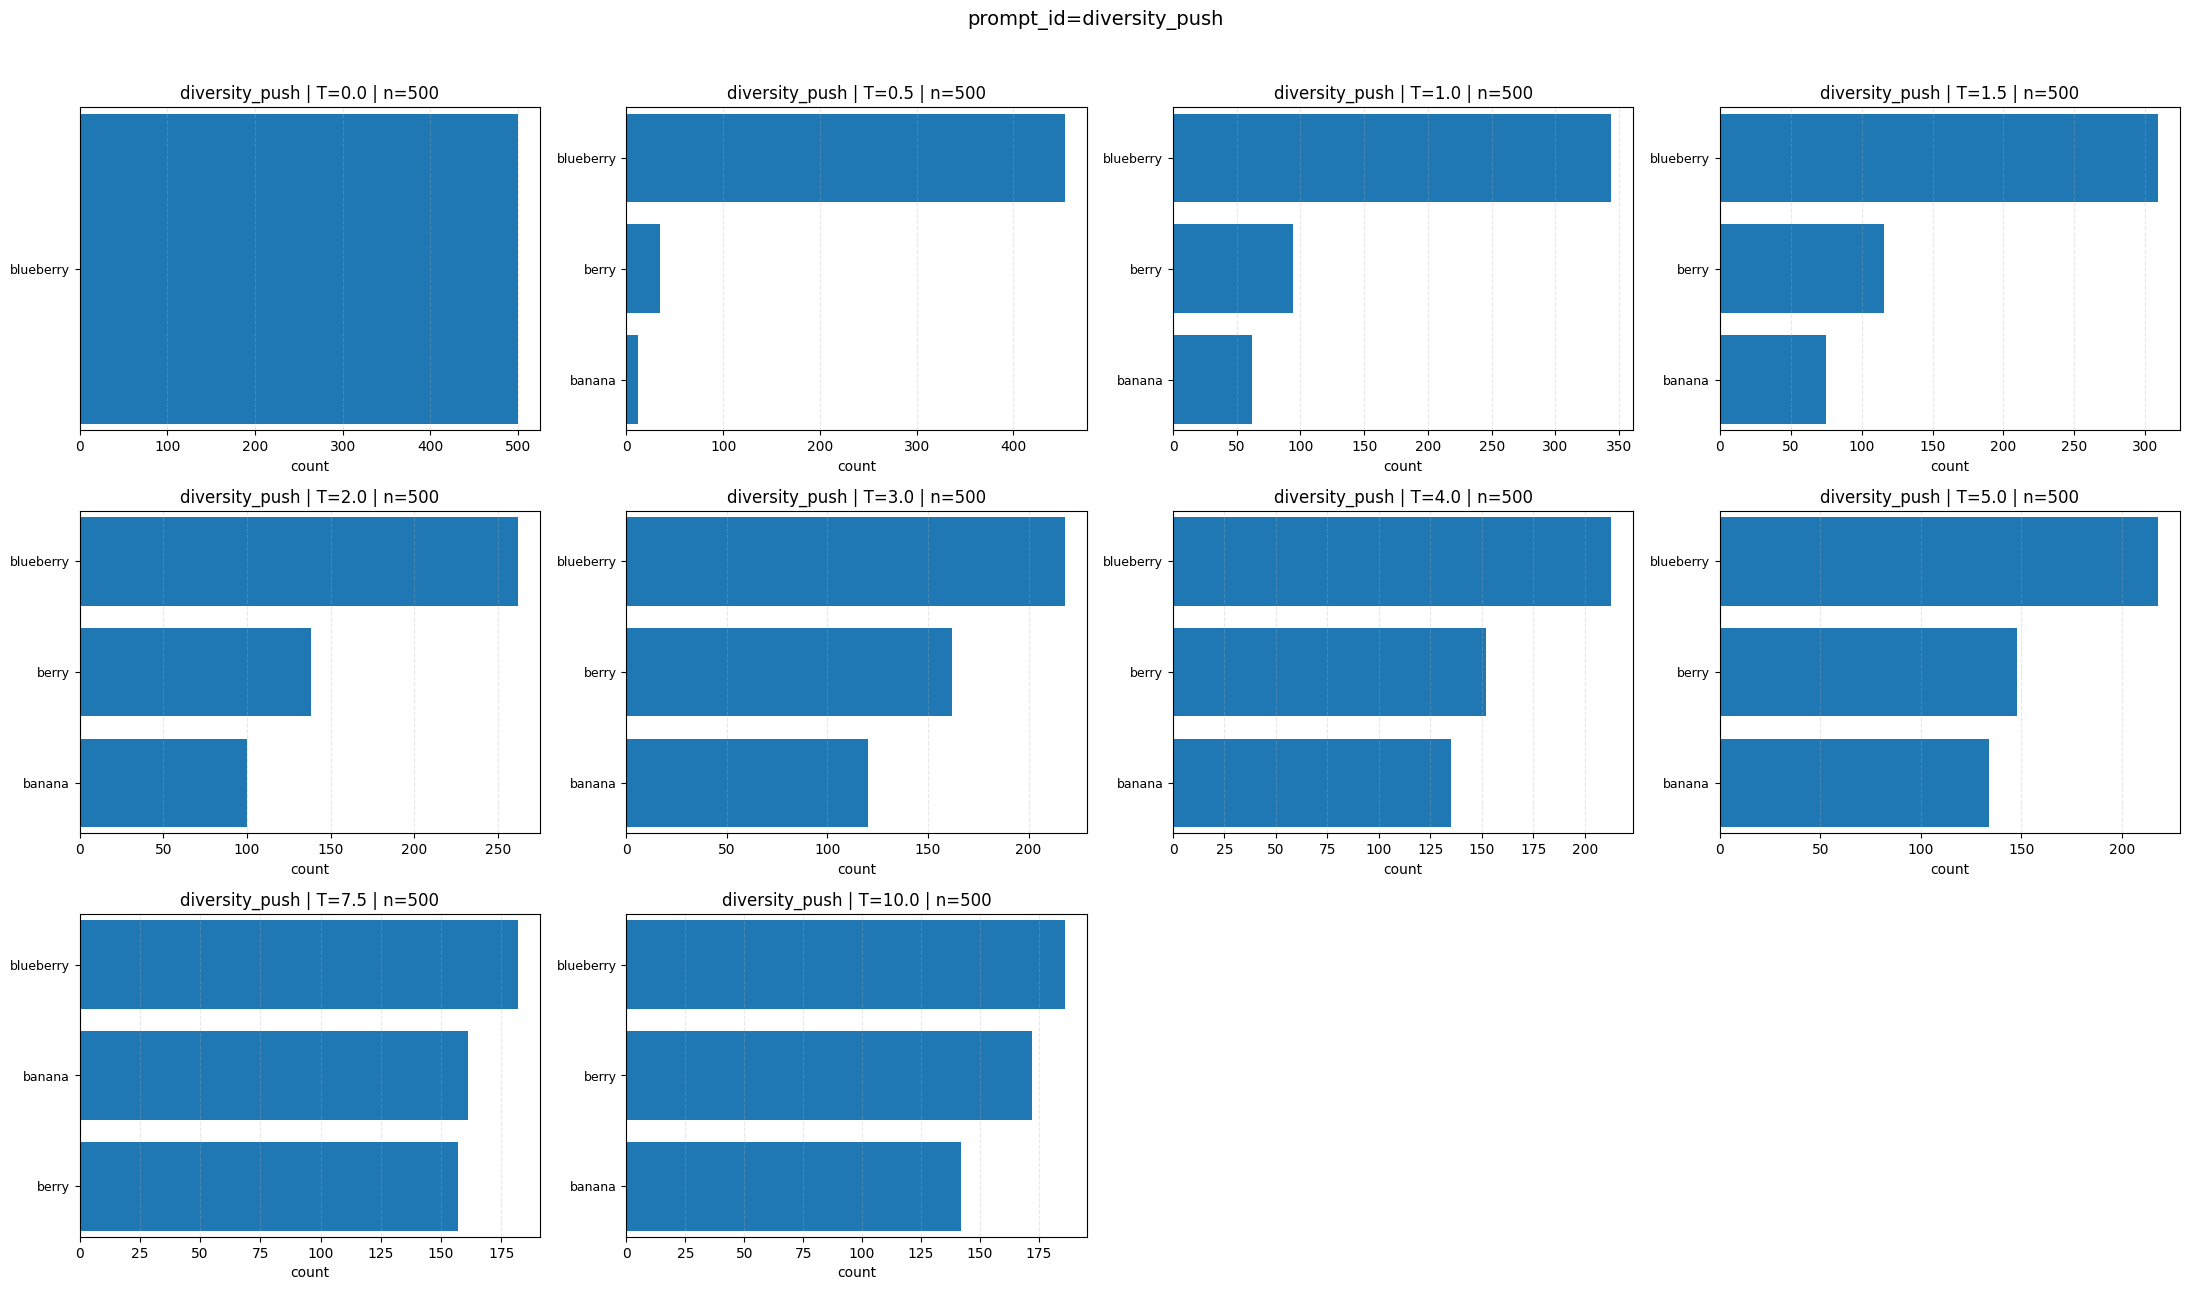

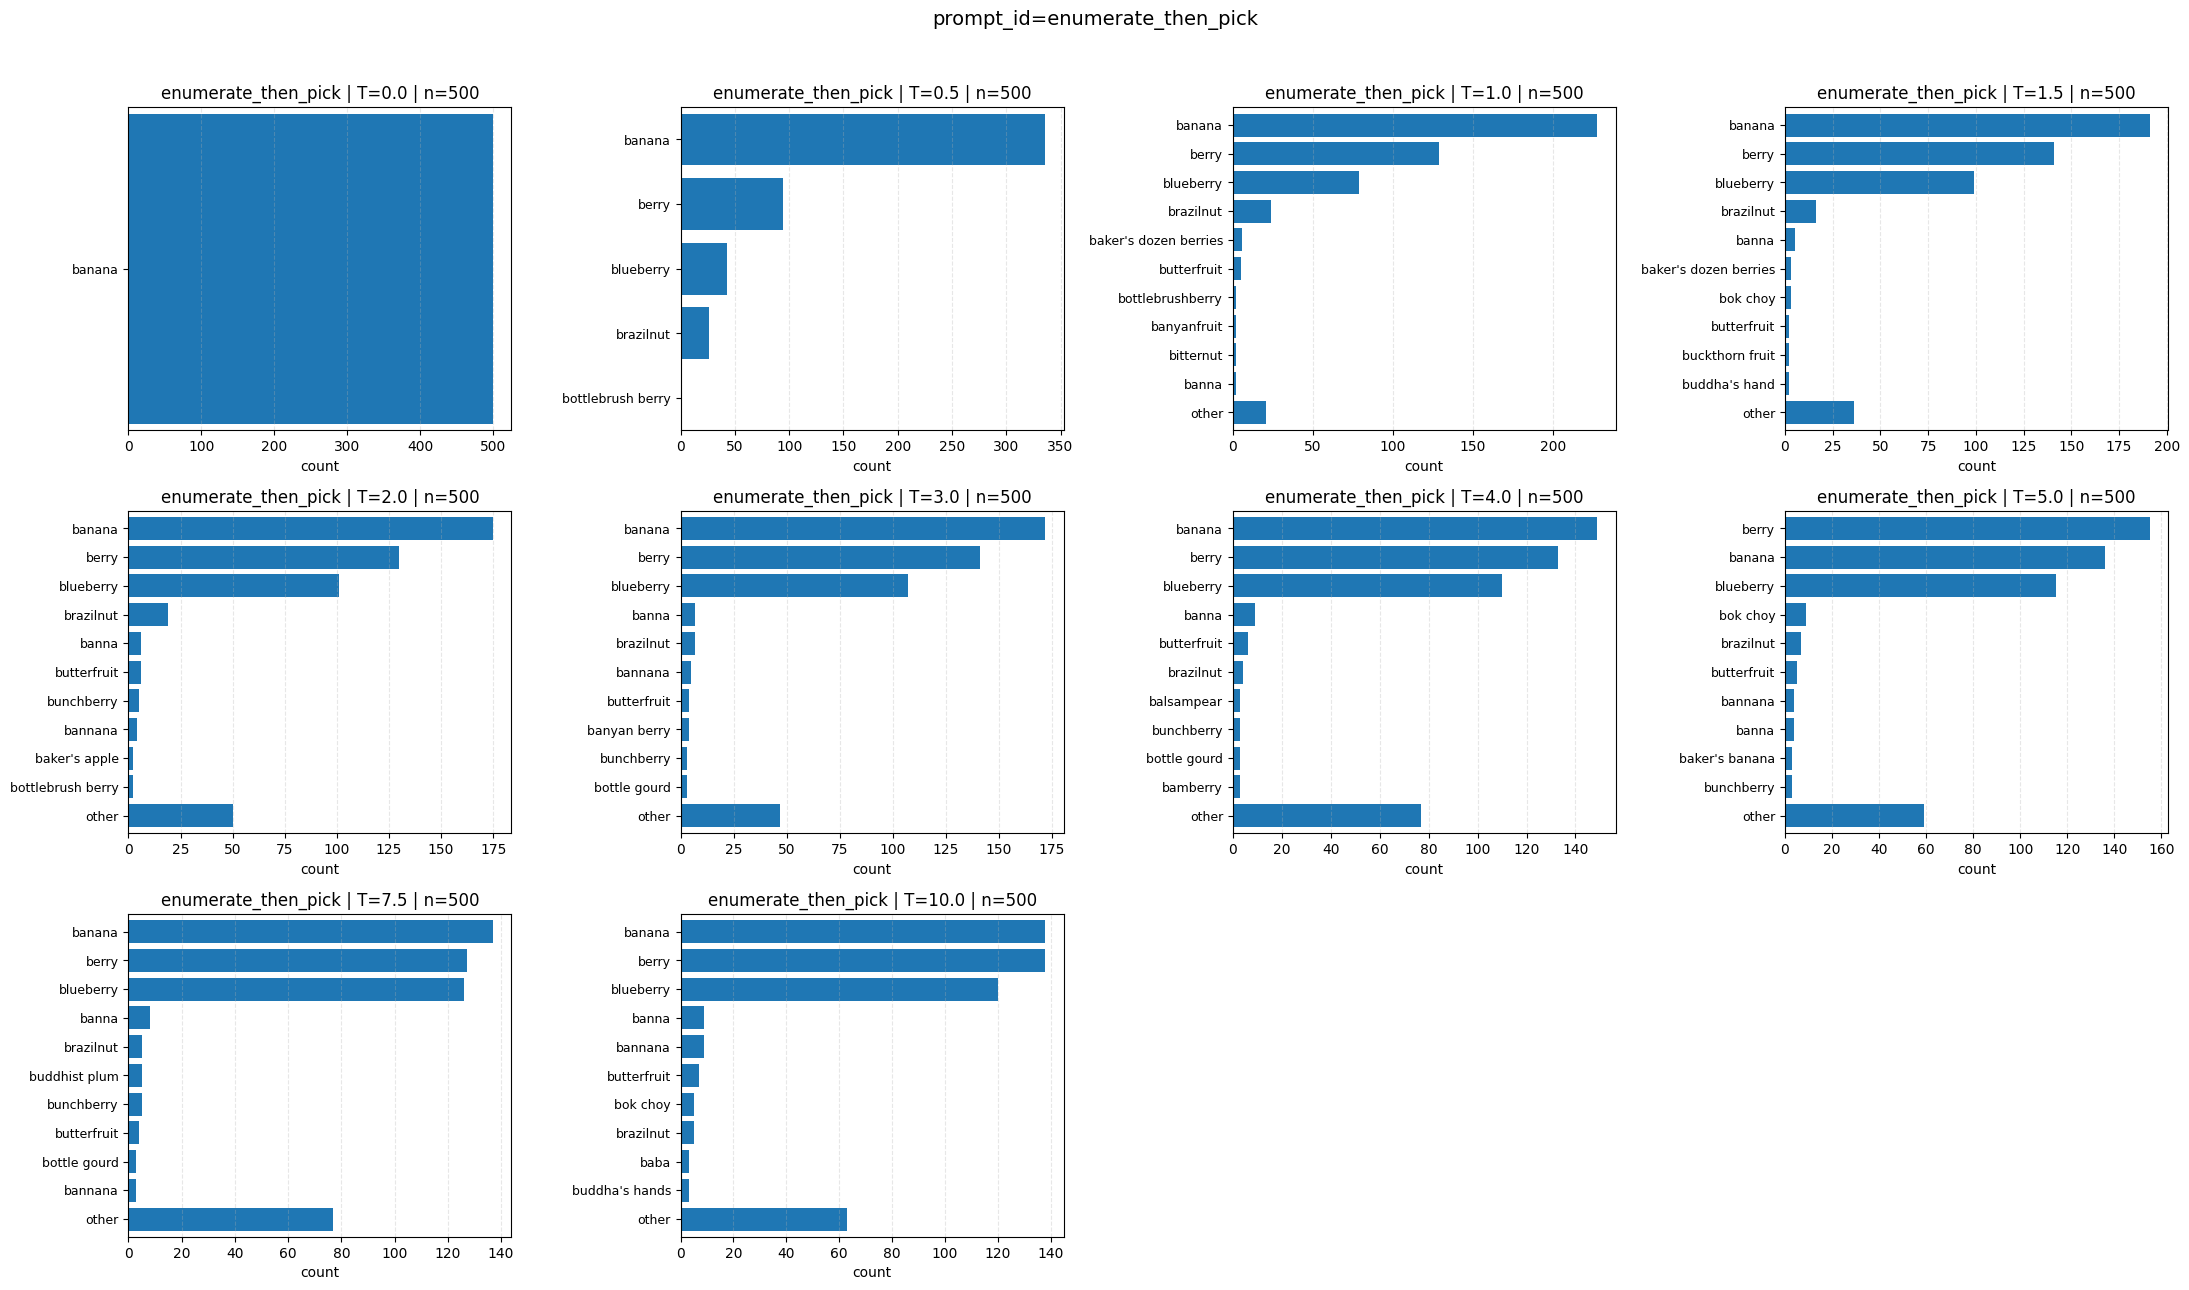

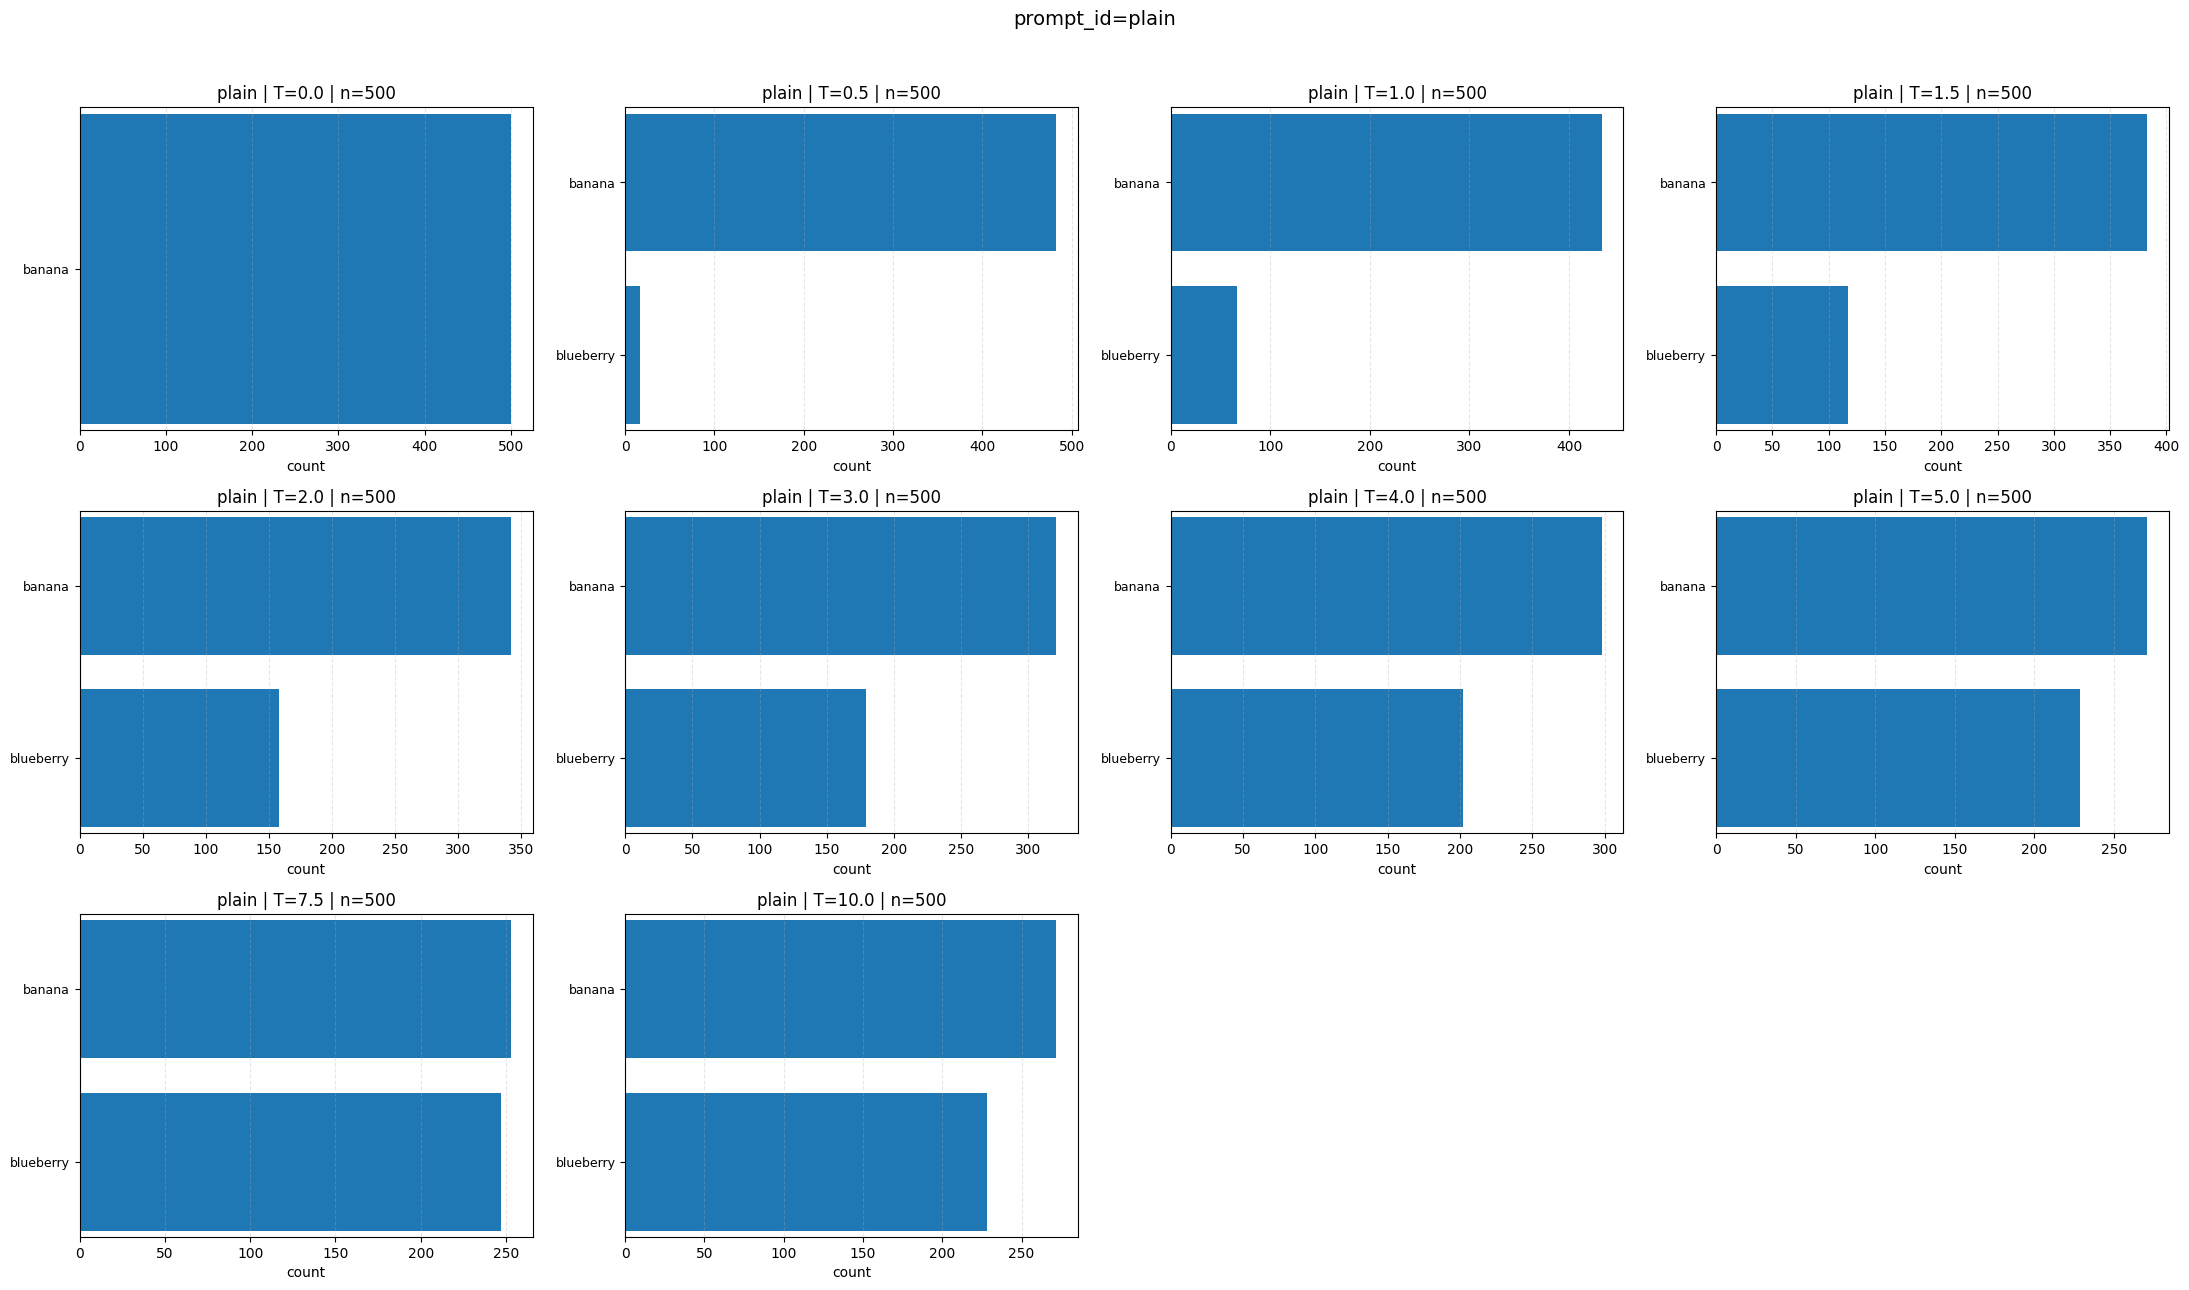

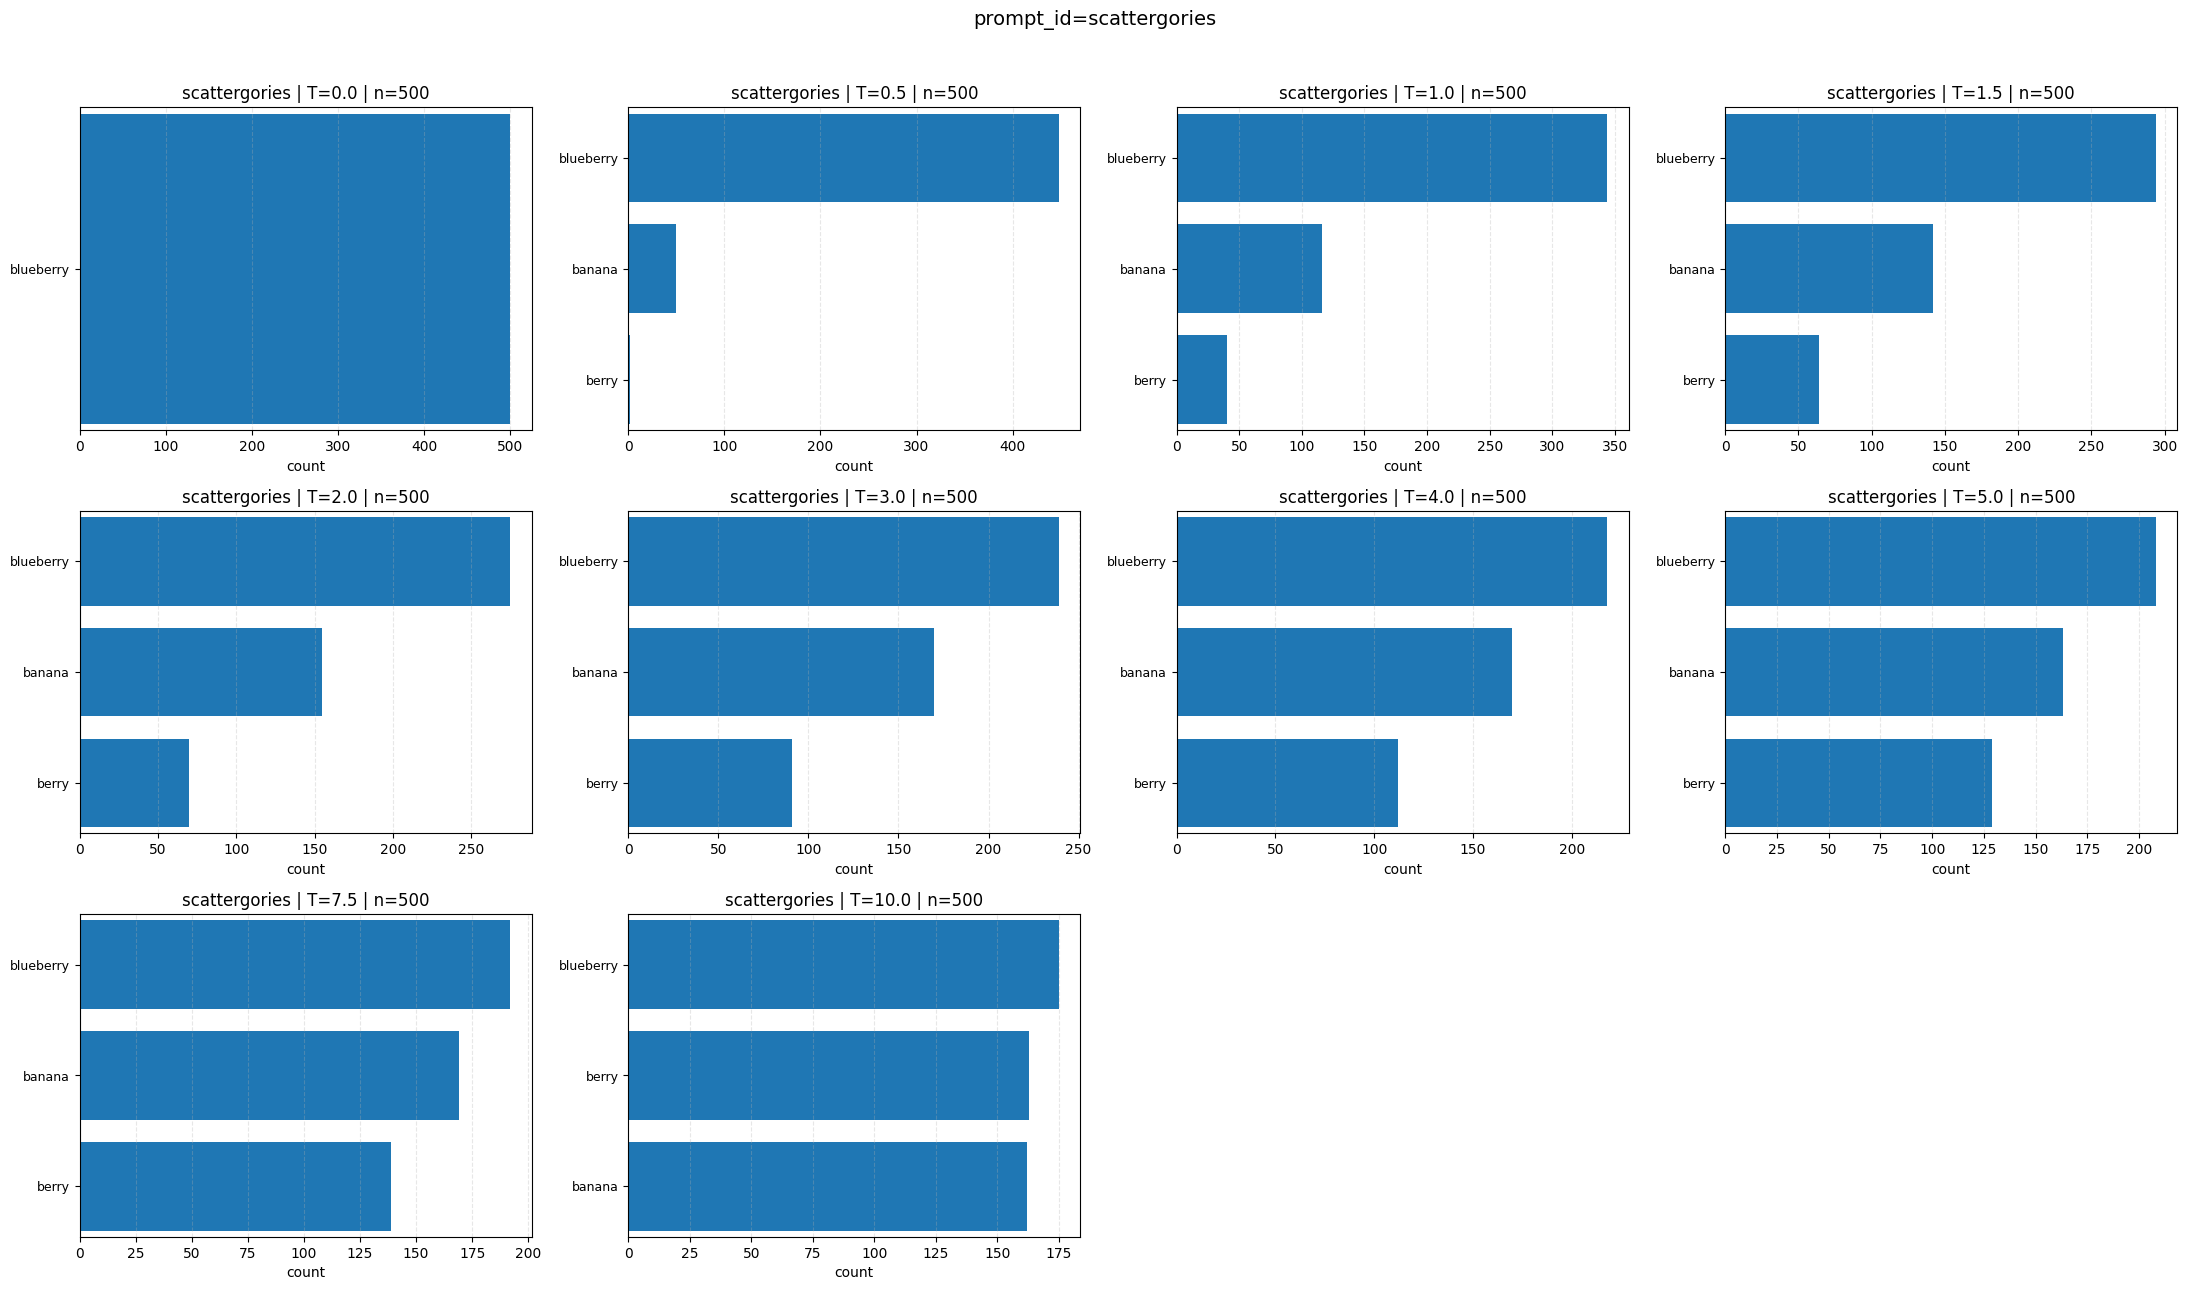

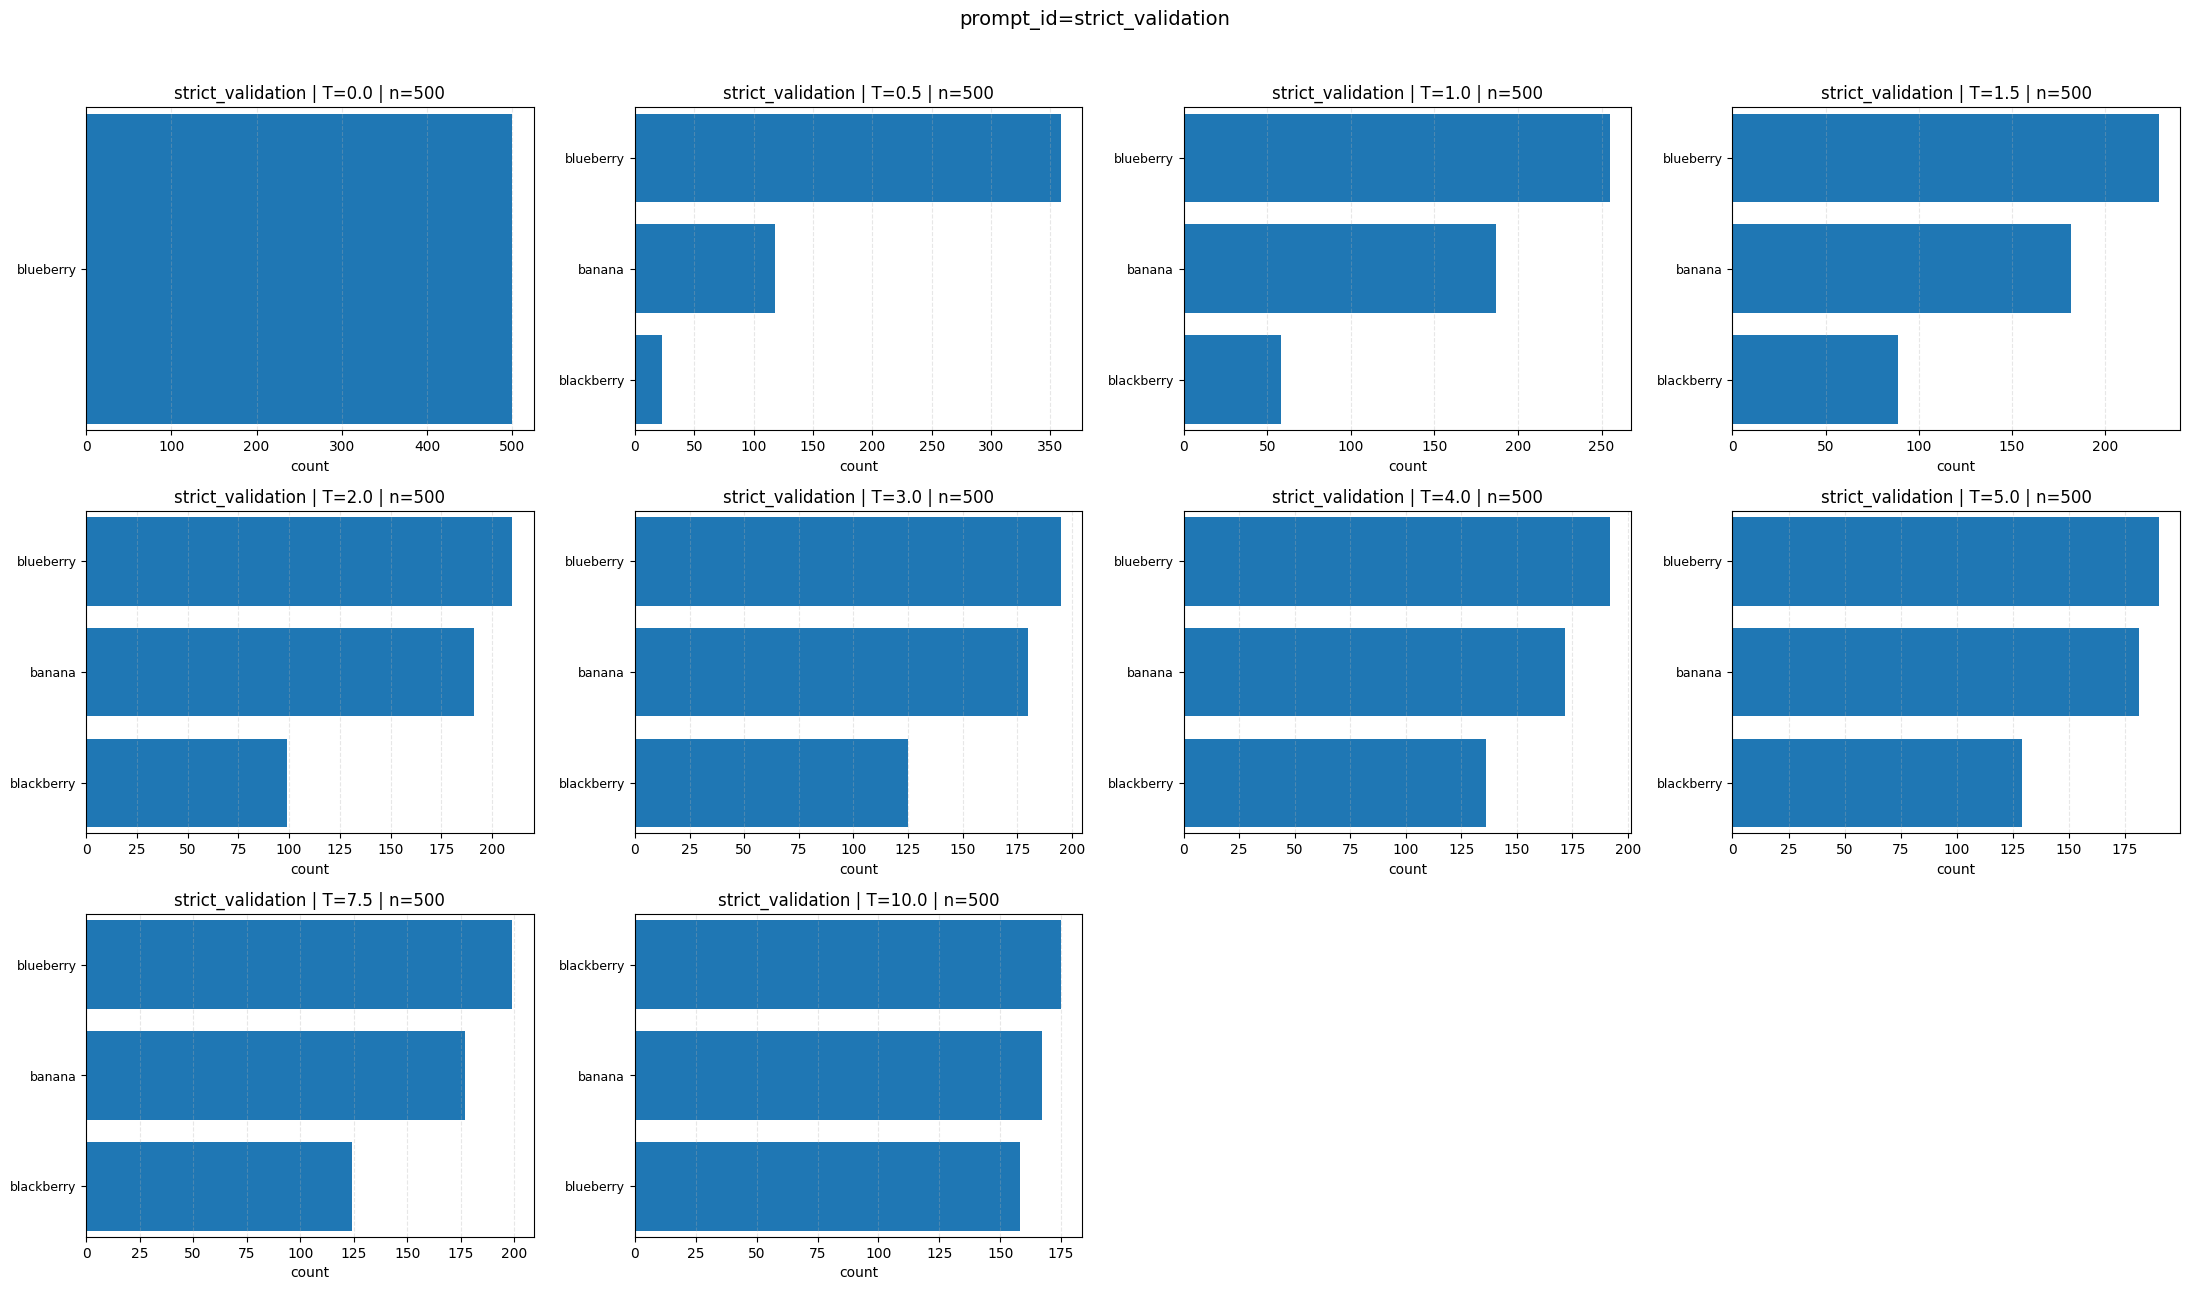

In [ ]:
base = Path("outputs/fruitb")
files = sorted(base.glob("*/calibration_fruitb_samples.csv"))

if not files:
    raise FileNotFoundError(f"No sample files found under {base.resolve()}")

df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

df["answer_norm"] = df["answer_norm"].fillna("").astype(str)
df["temperature"] = df["temperature"].astype(float)

prompts = sorted(df["prompt_id"].unique())
temps = sorted(df["temperature"].unique())

TOPK = 10               
N_COLS = 4             
FIG_W, FIG_H = 5.5, 4.2 

def topk_with_other(series, topk=10):
    vc = series.value_counts()
    if len(vc) <= topk:
        return vc
    head = vc.iloc[:topk]
    other = vc.iloc[topk:].sum()
    return pd.concat([head, pd.Series({"other": other})])

for pid in prompts:
    sub = df[df["prompt_id"] == pid]
    n = len(temps)
    ncols = min(N_COLS, n)
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(FIG_W * ncols, FIG_H * nrows),
        sharex=False, sharey=False
    )
    if nrows == 1 and ncols == 1:
        axes = [[axes]]
    elif nrows == 1:
        axes = [list(axes)]
    else:
        axes = [list(row) for row in axes]

    for idx, t in enumerate(temps):
        r, c = divmod(idx, ncols)
        ax = axes[r][c]

        st = sub[sub["temperature"] == t]
        counts = topk_with_other(st["answer_norm"], TOPK)

        labels = counts.index.tolist()[::-1]
        values = counts.values.tolist()[::-1]
        ax.barh(labels, values)

        ax.set_title(f"{pid} | T={t} | n={len(st)}")
        ax.set_xlabel("count")
        ax.set_ylabel("")

        ax.tick_params(axis="y", labelsize=9)
        ax.grid(axis="x", linestyle="--", alpha=0.3)

        ax.margins(y=0.02)

    for j in range(n, nrows * ncols):
        r, c = divmod(j, ncols)
        fig.delaxes(axes[r][c])

    fig.suptitle(f"prompt_id={pid}", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.savefig(f"outputs/fruitb/_img/distribution_vs_temp_day_{pid}.png", dpi=120, bbox_inches="tight")
    plt.show()

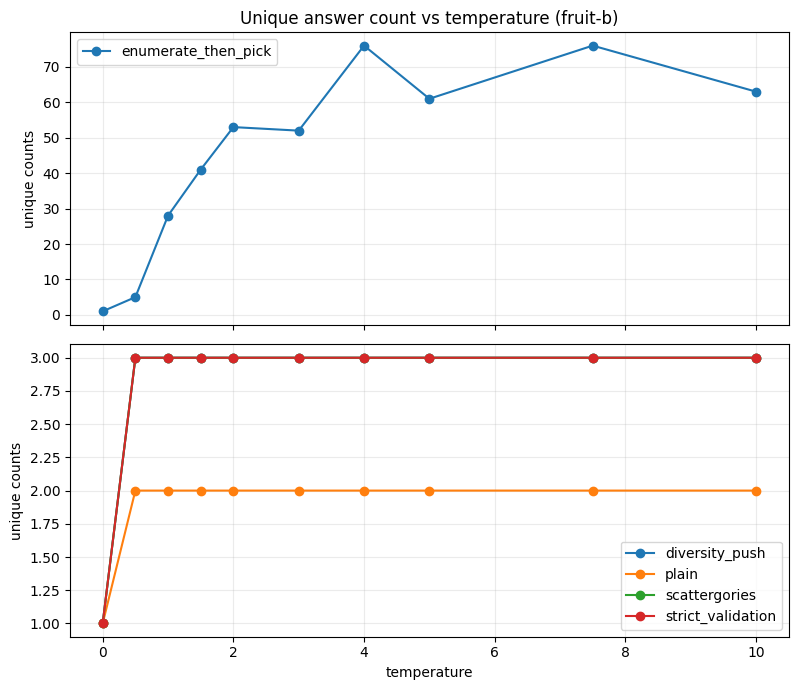

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

base = Path("outputs/fruitb")
summary_files = sorted(base.glob("*/calibration_fruitb_summary.json"))
df = pd.concat([pd.read_json(f) for f in summary_files], ignore_index=True)

df["temperature"] = df["temperature"].astype(float)
df["unique_answers"] = df["unique_answers"].astype(int)

big = "enumerate_then_pick"
df_big = df[df["prompt_id"] == big]
df_small = df[df["prompt_id"] != big]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8,7), sharex=True, height_ratios=[2, 2])

g = df_big.sort_values("temperature")
ax1.plot(g["temperature"], g["unique_answers"], marker="o", label=big)
ax1.set_ylabel("unique counts")
ax1.set_title("Unique answer count vs temperature (fruit-b)")
ax1.legend()
ax1.grid(alpha=0.25)

for pid, g in df_small.groupby("prompt_id"):
    g = g.sort_values("temperature")
    ax2.plot(g["temperature"], g["unique_answers"], marker="o", label=pid)

ax2.set_xlabel("temperature")
ax2.set_ylabel("unique counts")
ax2.legend()
ax2.grid(alpha=0.25)

plt.tight_layout()
plt.savefig(f"outputs/uniqueanswers_vs_temp_fruitb.png", dpi=120, bbox_inches="tight")
plt.show()